In [58]:
import logging

logger = logging.getLogger(__name__)

import counterfactual_graph_generation
import pandas as pd
import numpy as np
from counterfactual_graph_generation.data.make_dataset import CounterfactualGraphDataModule
from matplotlib import pyplot as plt
from collections import Counter
from omegaconf import OmegaConf

### A notebook with the purpose of visulizing statistics on the preprocessed graphs
def get_data_module(cfg):
    logger.info("Load data module, prepare- and setup data...")
    data_module = CounterfactualGraphDataModule(**cfg)
    data_module.prepare_data()
    return data_module

In [69]:

aids_config = OmegaConf.load('./config/dataset/aids.yaml')
mutagenicity_config = OmegaConf.load('./config/dataset/mutagenicity.yaml')
nci1_config = OmegaConf.load('./config/dataset/nci1.yaml')
proteins_config = OmegaConf.load('./config/dataset/proteins.yaml')
ogbg_molhiv_config = OmegaConf.load('./config/dataset/ogbg-molhiv.yaml')

config = ogbg_molhiv_config

In [70]:
dm = get_data_module(config)
dm.setup()

Downloaded 0.00 GB: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.52it/s]
Processing...


Extracting data/ogb-molhiv/sparse/hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41127/41127 [00:00<00:00, 120273.75it/s]


Converting graphs into PyG objects...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41127/41127 [00:01<00:00, 30078.22it/s]


Saving...


Done!


In [71]:
# Size of dataset:
print("Train dataset size: ", len(dm.data_train))
print("Validation dataset size: ", len(dm.data_val))
print("Test dataset size: ", len(dm.data_test))
print("Total size: ",  len(dm.dataset))

Train dataset size:  25849
Validation dataset size:  2877
Test dataset size:  3231
Total size:  31957


#### To be run for DENSE tensor representations:

### To be run for OGBM dataset with data output

In [72]:
# Find number of node attributes
print("Number of node attributes: ", dm.dataset[0].x.shape[1])
has_edge_attributes = dm.dataset[0].edge_attr != None
print("Has edge attributes? ", has_edge_attributes)
if has_edge_attributes:
    print("Number of edge attributes: ", dm.dataset[0].edge_attr.shape[1])

Number of node attributes:  9
Has edge attributes?  True
Number of edge attributes:  3


In [73]:
# Find largest graph in dataset
max_num_nodes = 0
num_nodes = np.zeros(len(dm.dataset))
all_labels = np.zeros(len(dm.dataset))
for i, graph in enumerate(dm.dataset):
    max_num_nodes = max(graph.x.shape[0], max_num_nodes)
    num_nodes[i] = graph.x.shape[0]
    all_labels[i] = graph.y.item()

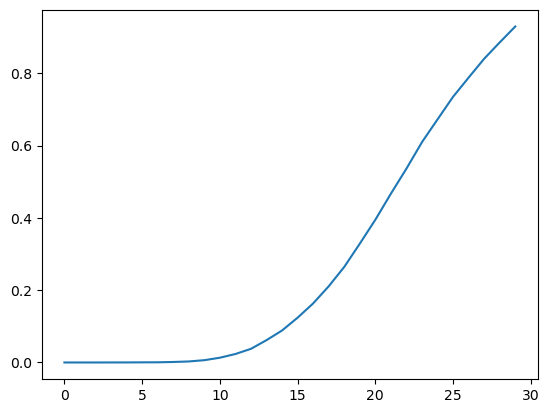

In [74]:
# Number of graphs with number of nodes below threshold
y = []
x = list(range(30))
n = len(dm.dataset)
for i in x:
    y.append((num_nodes < i).sum()/n)

plt.plot(x, y)

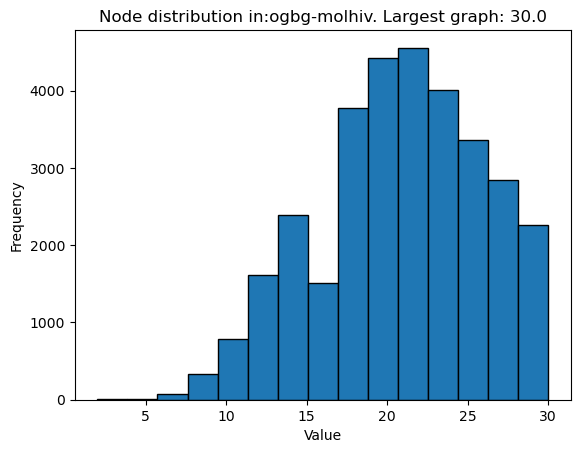

In [75]:
# Plot distribution
title = "Node distribution in:" + config['dataset_name'] + ". Largest graph: " + str(max(num_nodes))
xlabel = "Value"
ylabel = "Frequency"
plt.hist(num_nodes, bins=15, edgecolor='black')
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.show()

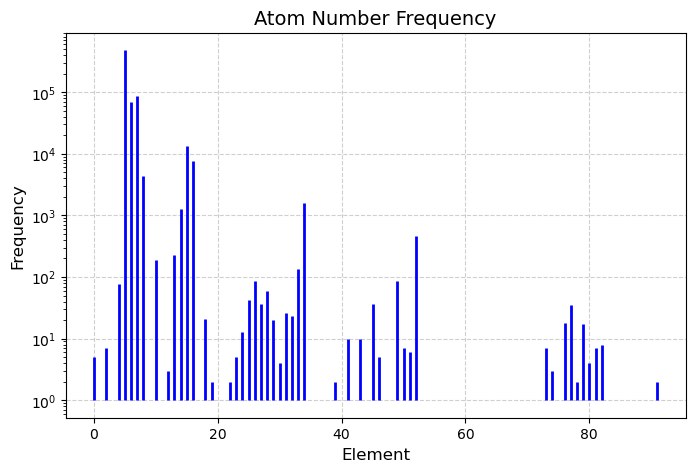

In [76]:
all_nodes = dm.dataset[:].x
arr = all_nodes[:,0]

# Step 1: Calculate the unique elements and their frequencies
unique_elements, frequencies = np.unique(arr, return_counts=True)
# Step 2: Plot the frequencies of each element
plt.figure(figsize=(8, 5))
plt.vlines(unique_elements, ymin=1, ymax=frequencies, color='b', linewidth=2)
plt.yscale('log')
# Step 3: Adding labels and title
plt.title('Atom Number Frequency', fontsize=14)
plt.xlabel('Element', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

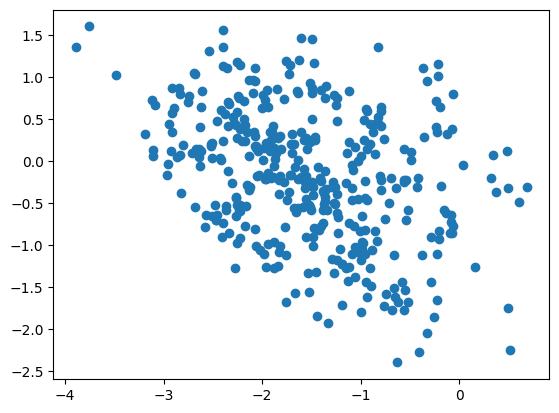

In [114]:
# Testing embedding functionality:

from ogb.graphproppred.mol_encoder import AtomEncoder, BondEncoder
atom_encoder = AtomEncoder(emb_dim = 2)
bond_encoder = BondEncoder(emb_dim = 2)

atom_emb = atom_encoder(graph.x) # x is input atom feature
edge_emb = bond_encoder(graph.edge_attr) # edge_attr is input edge f

unq_embedding = atom_encoder(all_nodes).unique(dim=0)

plt.scatter(unq_embedding[:,0].detach(), unq_embedding[:,1].detach())

In [99]:
def get_label_frequencies(dataset):
    labels = []
    for i, graph in enumerate(dataset):
        labels.append(graph.y.item())
    ones = np.array(labels).sum()
    zeros = len(labels) - np.array(labels).sum()
    return np.array([zeros / len(labels), ones / len(labels)])

all_labels_train = get_label_frequencies(dm.data_train)
all_labels_val = get_label_frequencies(dm.data_val)
all_labels_test = get_label_frequencies(dm.data_test)

frequencies = np.stack([all_labels_train, all_labels_val, all_labels_test], axis=0)

print(frequencies)

[[0.97156563 0.02843437]
 [0.98713938 0.01286062]
 [0.98359641 0.01640359]]


In [101]:
# The dataset is very schewed - not many are HIV positve.
# Show the distribution between different classes
#counter = Counter(all_labels)
#labels, frequencies = zip(*counter.items())
#frequencies = (frequencies[0]/(frequencies[0] + frequencies[1]), frequencies[1]/(frequencies[0] + frequencies[1]))
#print("Frequencies: ", frequencies)
#title = "Class label occurence"
#xlabel = "Class"
#ylabel = "Frequency"
#plt.vlines([0, 1], ymin=0, ymax=frequencies, color='b', linewidth=10)
#plt.title(title)
#plt.xlabel(xlabel)
#plt.ylabel(ylabel)
#plt.show()

### Add node count logistic regression classifier

In [157]:

import sklearn
from sklearn.linear_model import LogisticRegression


def get_dataframe(dataset):
    x = [] # Number of nodes
    y = [] # classes of nodes
    for i, item in enumerate(dataset):
        x.append(item.num_nodes)
        y.append(item.y.item())
    return pd.DataFrame(np.array([x, y]).T)

df_train = get_dataframe(dm.data_train)
df_val = get_dataframe(dm.data_val)
df_test = get_dataframe(dm.data_test)


Text(0.5, 0, 'Node Count')

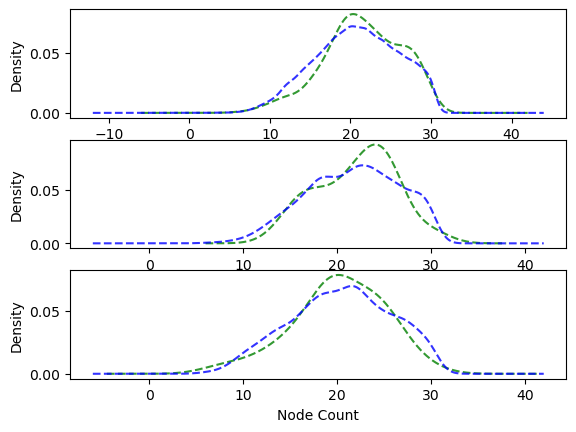

In [163]:
import pandas as pd

fig, axs = plt.subplots(3)

df_train[df_train[1]==1].iloc[:,0].plot(kind='density',alpha=0.8, color='green',linestyle='--', label='Factual Label 1', ax=axs[0])
df_train[df_train[1]==0].iloc[:,0].plot(kind='density',alpha=0.8, color='blue',linestyle='--', label='Factual Label 1', ax=axs[0])
df_val[df_val[1]==1].iloc[:,0].plot(kind='density',alpha=0.8, color='green',linestyle='--', label='Factual Label 1', ax=axs[1])
df_val[df_val[1]==0].iloc[:,0].plot(kind='density',alpha=0.8, color='blue',linestyle='--', label='Factual Label 1', ax=axs[1])
df_test[df_test[1]==1].iloc[:,0].plot(kind='density',alpha=0.8, color='green',linestyle='--', label='Factual Label 1', ax=axs[2])
df_test[df_test[1]==0].iloc[:,0].plot(kind='density',alpha=0.8, color='blue',linestyle='--', label='Factual Label 1', ax=axs[2])
plt.xlabel('Node Count')

/home/andab/.conda/envs/cfg/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


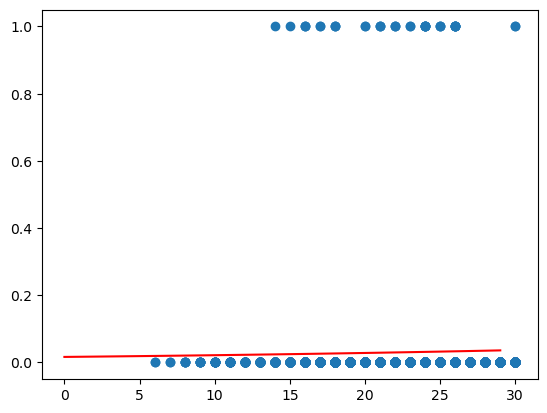

In [238]:

model = LogisticRegression(solver='newton-cholesky')#, class_weight='balanced')
model.fit(np.array(df_train[0]).reshape(-1,1), np.array(df_train[1]).reshape(-1,1))
pred_prob = model.predict_proba(np.array(range(1,31)).reshape(-1,1))

plt.scatter(x, y)
plt.plot(pred_prob[:,1], c='red')

In [241]:
df = df_val
preds = model.predict(np.array(df[0]).reshape(-1,1))

In [242]:
# Balanced accuracy
c0 = (df[0 == df[1]][1] == preds[0 == df[1]]).sum()
c1 = (df[1 == df[1]][1] == preds[1 == df[1]]).sum()
0.5 * (c0 / len(df[0 == df[1]]) + c1 / len(df[1 == df[1]]))

0.5

### Summary:
- Capping the number of nodes at 30 will retain approximately 80& of the data.
- Nearly all the molecules (96.5%) are negative examples, i.e. non-hiv. This will impact the ability to find counterfactuals.
- 